# Behavioral Segmentation for Targeted Marketing
## Phase 1 — Data Loading & Exploratory Data Analysis (EDA)


In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("retail_finding_dataa.csv")

In [3]:
df.sample(5)

,Customer_ID,Age,Gender,Region,Annual_Spending,Purchase_Frequency,Discount_Usage_Pct,Returns_Count,Preferred_Category
33,CUST0034,50,Non-Binary,West,7648.48,12,31.4,0,Groceries
771,CUST0772,45,Non-Binary,Central,1704.03,8,5.7,1,Travel
806,CUST0807,46,Non-Binary,West,6139.79,14,25.9,2,Home & Living
872,CUST0873,27,Female,Central,342.02,1,59.1,0,Health
291,CUST0292,43,Male,West,1884.90,5,54.4,0,Groceries


In [4]:
df.head()

,Customer_ID,Age,Gender,Region,Annual_Spending,Purchase_Frequency,Discount_Usage_Pct,Returns_Count,Preferred_Category
0,CUST0001,27,Male,North,855.00,6,52.9,0,Health
1,CUST0002,47,Non-Binary,West,10791.93,21,24.5,4,Books
2,CUST0003,47,Female,North,7345.63,12,13.3,0,Beauty
3,CUST0004,55,Female,Central,18169.93,36,18.8,1,Books
4,CUST0005,54,Male,South,570.49,2,9.5,0,Sports


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         1000 non-null   object 
 1   Age                 1000 non-null   int64  
 2   Gender              1000 non-null   object 
 3   Region              1000 non-null   object 
 4   Annual_Spending     1000 non-null   float64
 5   Purchase_Frequency  1000 non-null   int64  
 6   Discount_Usage_Pct  1000 non-null   float64
 7   Returns_Count       1000 non-null   int64  
 8   Preferred_Category  1000 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [6]:
df.shape

(1000, 9)

In [7]:
df.size

9000

In [8]:
df.describe()

,Age,Annual_Spending,Purchase_Frequency,Discount_Usage_Pct,Returns_Count
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,38.207000,4567.573800,12.528000,29.126500,1.249000
std,10.434128,4908.758211,12.276316,17.061921,1.641247
min,18.000000,50.790000,1.000000,5.000000,0.000000
25%,30.000000,762.382500,3.000000,15.700000,0.000000
50%,38.000000,2659.555000,9.000000,25.600000,1.000000
75%,45.000000,6733.765000,17.000000,38.275000,2.000000
max,70.000000,19907.090000,52.000000,70.000000,10.000000


In [9]:
df.isnull().sum()

Customer_ID           0
Age                   0
Gender                0
Region                0
Annual_Spending       0
Purchase_Frequency    0
Discount_Usage_Pct    0
Returns_Count         0
Preferred_Category    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
for col in df.select_dtypes(include='object').columns:
    print(col, ':', df[col].unique())

Customer_ID : ['CUST0001' 'CUST0002' 'CUST0003' 'CUST0004' 'CUST0005' 'CUST0006'
 'CUST0007' 'CUST0008' 'CUST0009' 'CUST0010' 'CUST0011' 'CUST0012'
 'CUST0013' 'CUST0014' 'CUST0015' 'CUST0016' 'CUST0017' 'CUST0018'
 'CUST0019' 'CUST0020' 'CUST0021' 'CUST0022' 'CUST0023' 'CUST0024'
 'CUST0025' 'CUST0026' 'CUST0027' 'CUST0028' 'CUST0029' 'CUST0030'
 'CUST0031' 'CUST0032' 'CUST0033' 'CUST0034' 'CUST0035' 'CUST0036'
 'CUST0037' 'CUST0038' 'CUST0039' 'CUST0040' 'CUST0041' 'CUST0042'
 'CUST0043' 'CUST0044' 'CUST0045' 'CUST0046' 'CUST0047' 'CUST0048'
 'CUST0049' 'CUST0050' 'CUST0051' 'CUST0052' 'CUST0053' 'CUST0054'
 'CUST0055' 'CUST0056' 'CUST0057' 'CUST0058' 'CUST0059' 'CUST0060'
 'CUST0061' 'CUST0062' 'CUST0063' 'CUST0064' 'CUST0065' 'CUST0066'
 'CUST0067' 'CUST0068' 'CUST0069' 'CUST0070' 'CUST0071' 'CUST0072'
 'CUST0073' 'CUST0074' 'CUST0075' 'CUST0076' 'CUST0077' 'CUST0078'
 'CUST0079' 'CUST0080' 'CUST0081' 'CUST0082' 'CUST0083' 'CUST0084'
 'CUST0085' 'CUST0086' 'CUST0087' 'CUST0088' 'CU

### Observations from Initial Exploration:
1. The dataset has **1000 rows and 9 columns** — a clean, well-structured retail dataset.
2. There are **no missing values** and **no duplicate records**, so no data cleaning is required.
3. The key features for clustering are `Annual_Spending` and `Purchase_Frequency`, as specified.
4. Categorical columns: `Gender` (3 categories), `Region` (5 categories), `Preferred_Category` (10 categories).
5. `Customer_ID` is an identifier column and will be excluded from analysis.

In [12]:
for c in ['Gender', 'Region', 'Preferred_Category']:
    print(f"\n--- {c} ---")
    print(df[c].value_counts())


--- Gender ---
Gender
Non-Binary    367
Male          320
Female        313
Name: count, dtype: int64

--- Region ---
Region
North      225
West       203
South      198
Central    195
East       179
Name: count, dtype: int64

--- Preferred_Category ---
Preferred_Category
Books            115
Travel           114
Beauty           106
Fashion          104
Groceries        102
Health            95
Electronics       93
Dining            93
Sports            89
Home & Living     89
Name: count, dtype: int64


In [13]:
nc = ['Age', 'Annual_Spending', 'Purchase_Frequency', 'Discount_Usage_Pct', 'Returns_Count']
df[nc].skew()

Age                   0.383967
Annual_Spending       1.410179
Purchase_Frequency    1.555263
Discount_Usage_Pct    0.727411
Returns_Count         2.358881
dtype: float64

### Observations from Skewness:
1. `Annual_Spending` (skew ≈ 1.41) and `Purchase_Frequency` (skew ≈ 1.56) are both **right-skewed**, meaning a few high-spending, high-frequency customers pull the distribution.
2. `Age` and `Discount_Usage_Pct` are approximately symmetric.
3. Right-skewed features justify the use of StandardScaler in Phase 2 to normalize before clustering.

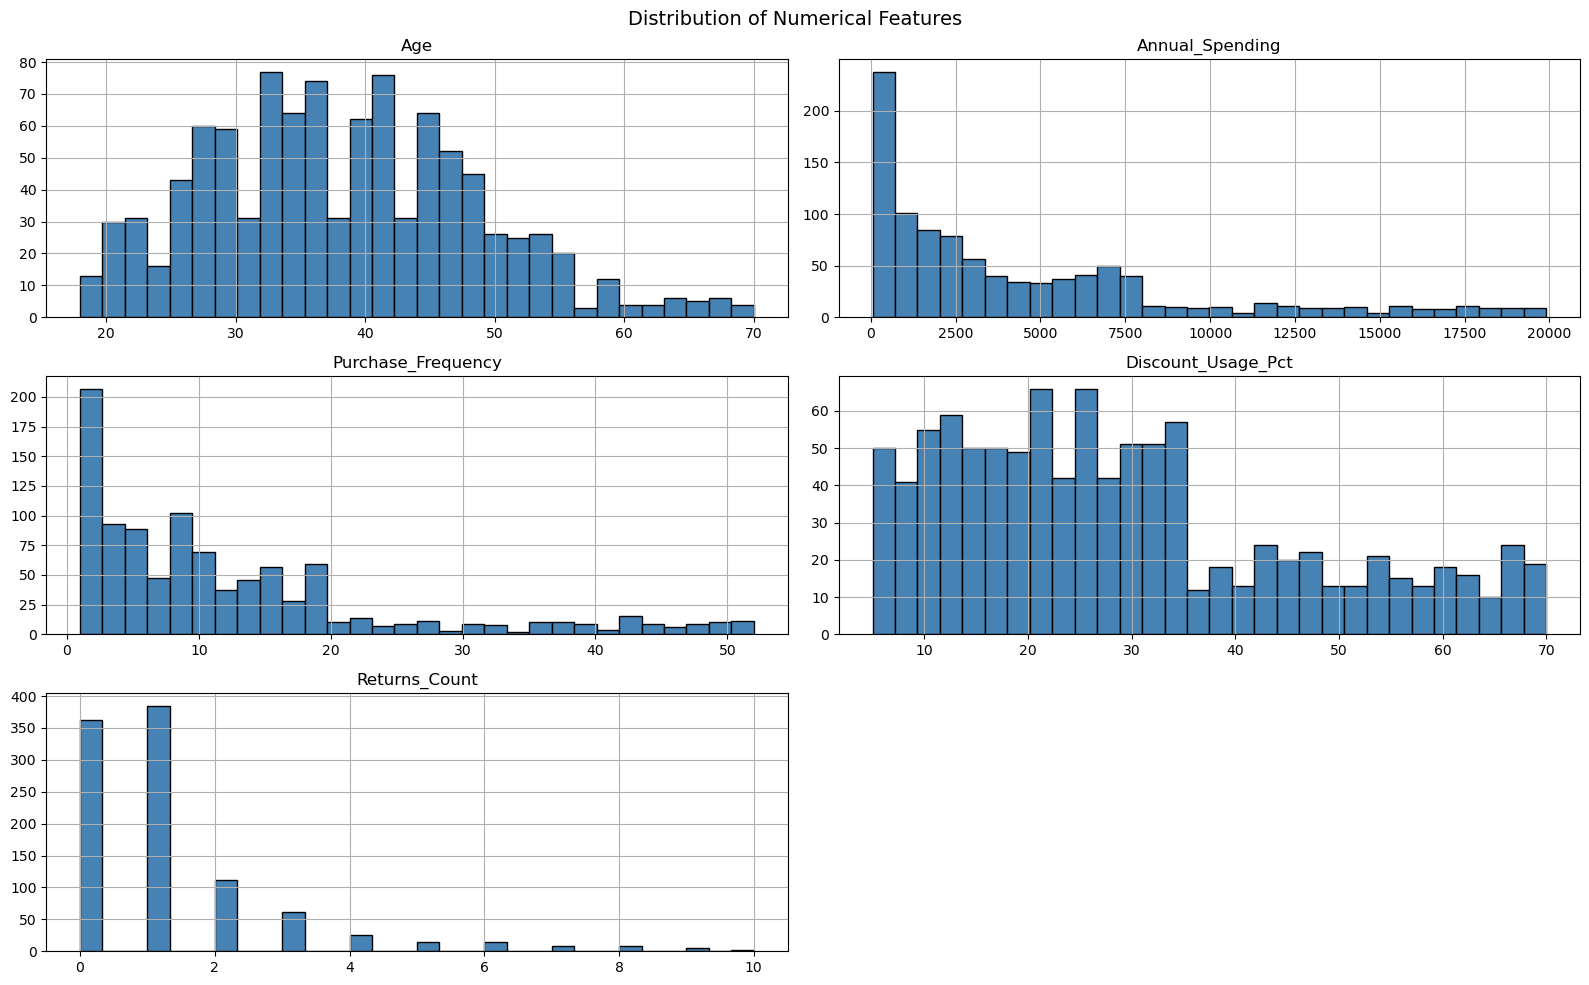

In [14]:
df[nc].hist(figsize=(16, 10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

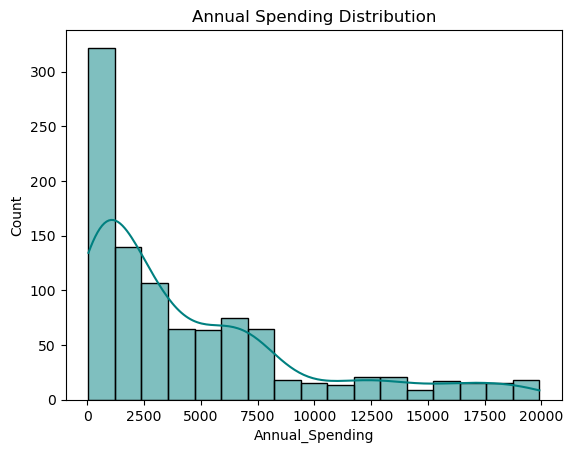

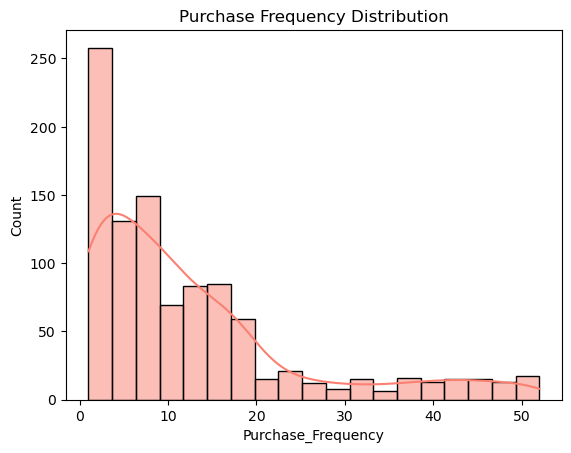

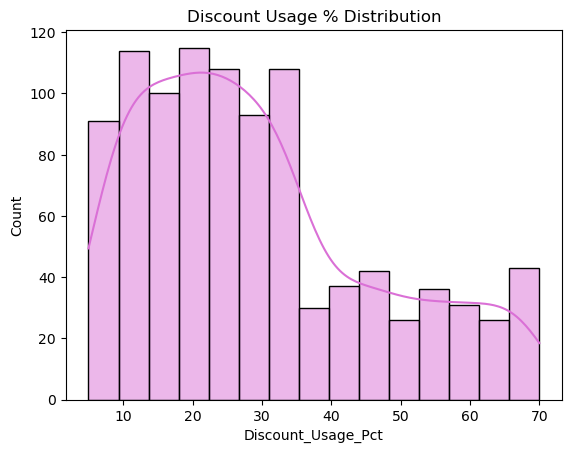

In [15]:
sns.histplot(df['Annual_Spending'], kde=True, color='teal')
plt.title('Annual Spending Distribution')
plt.show()

sns.histplot(df['Purchase_Frequency'], kde=True, color='salmon')
plt.title('Purchase Frequency Distribution')
plt.show()

sns.histplot(df['Discount_Usage_Pct'], kde=True, color='orchid')
plt.title('Discount Usage % Distribution')
plt.show()

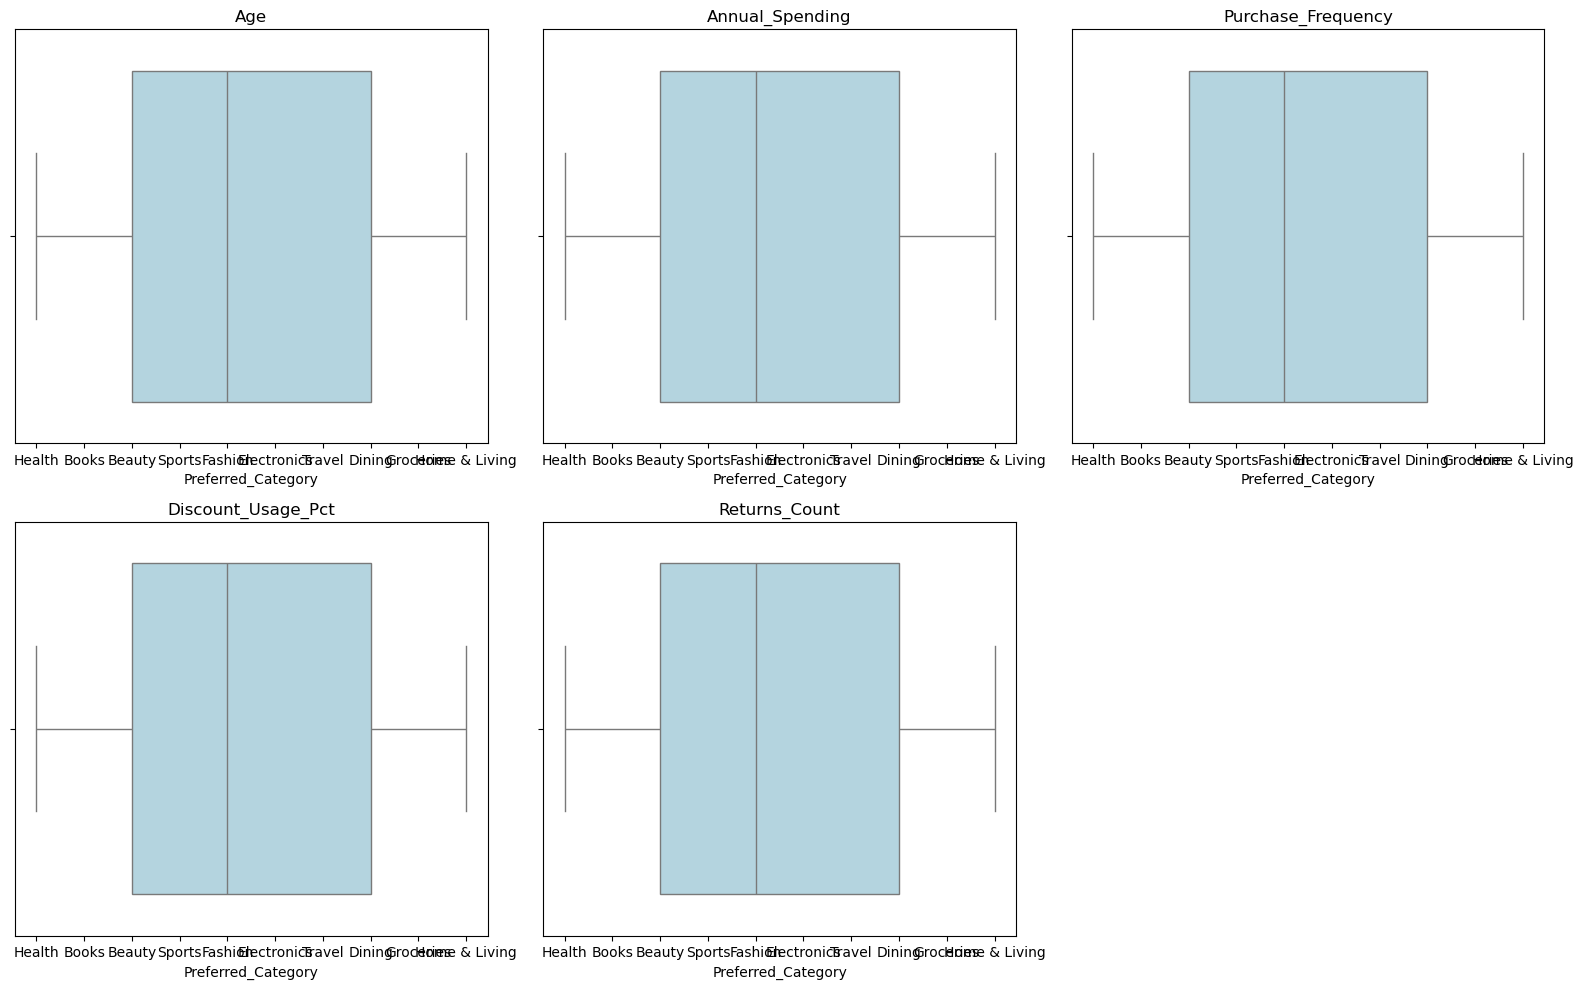

In [16]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(nc, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[c], color='lightblue')
    plt.title(col)

plt.tight_layout()
plt.show()

### Observations from Boxplots:
1. `Annual_Spending` has a wide spread with visible outliers — some customers are extreme high spenders.
2. `Purchase_Frequency` also shows outliers on the upper end, consistent with its right skew.
3. `Returns_Count` is mostly 0–2, but a few customers have high return counts.
4. Outliers in `Annual_Spending` and `Purchase_Frequency` represent real customer behavior (e.g., premium buyers) and should **not** be removed — they help define meaningful personas.

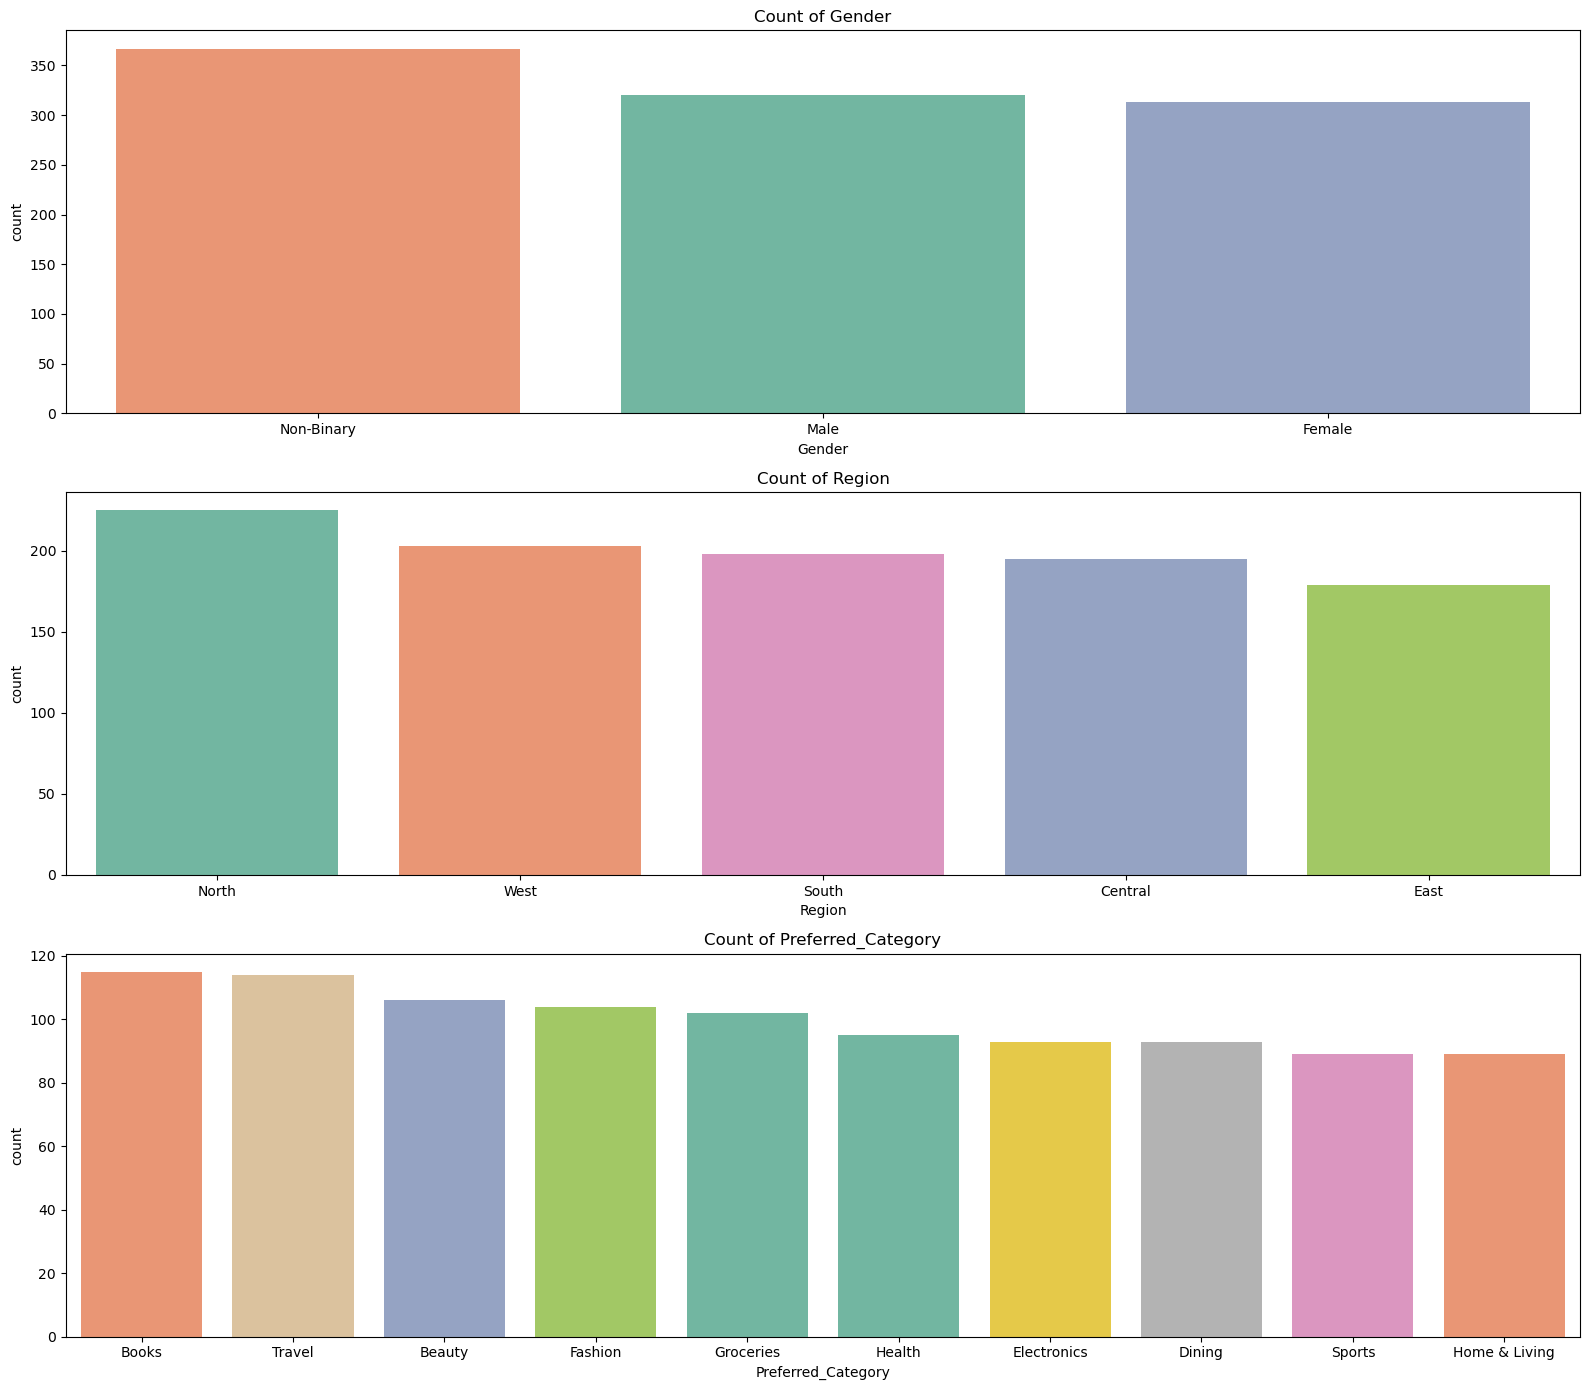

In [17]:
cat_cols = ['Gender', 'Region', 'Preferred_Category']

plt.figure(figsize=(16, 14))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 1, i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2', hue=col, legend=False)
    plt.title(f'Count of {col}')

plt.tight_layout()
plt.show()

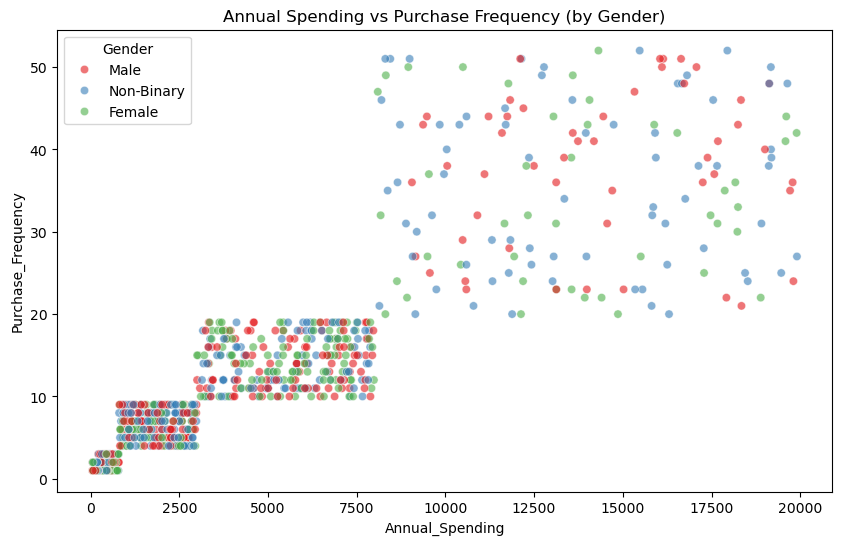

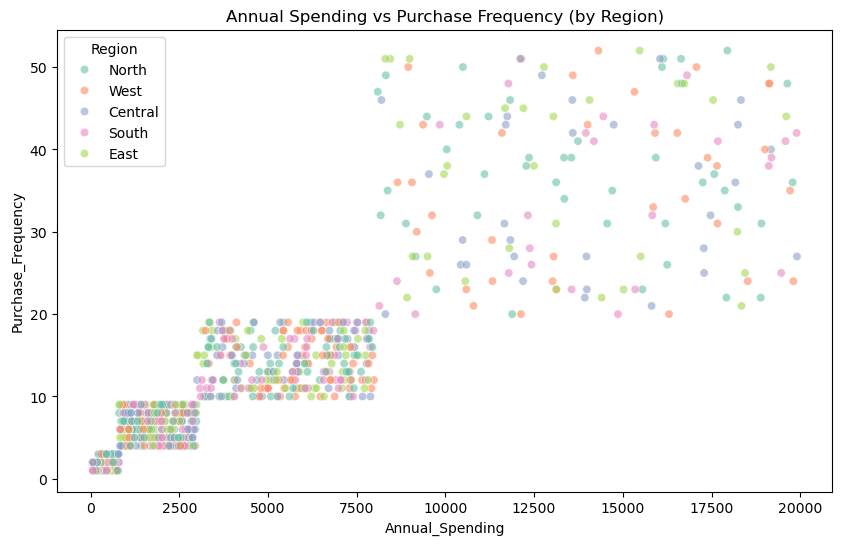

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Spending', y='Purchase_Frequency',
                hue='Gender', palette='Set1', alpha=0.6)
plt.title('Annual Spending vs Purchase Frequency (by Gender)')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Spending', y='Purchase_Frequency',
                hue='Region', palette='Set2', alpha=0.6)
plt.title('Annual Spending vs Purchase Frequency (by Region)')
plt.show()

In [19]:
df.groupby('Preferred_Category')[['Annual_Spending', 'Purchase_Frequency']].mean().sort_values(
    by='Annual_Spending', ascending=False)

,Annual_Spending,Purchase_Frequency
Preferred_Category,,
Books,5450.961304,14.321739
Fashion,5147.035192,13.605769
Groceries,4723.996961,13.117647
Dining,4678.315806,13.322581
Electronics,4615.337527,13.129032
Travel,4486.591316,12.570175
Health,4466.858947,12.052632
Home & Living,4125.976517,12.022472
Beauty,4103.393962,11.018868


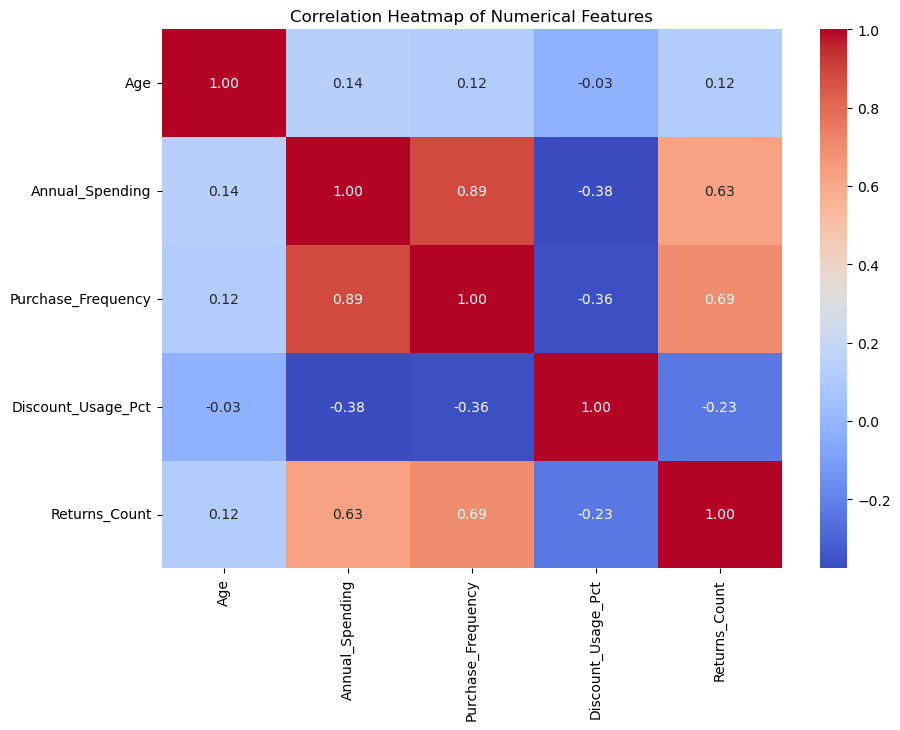

In [20]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[nc].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Observations from Correlation Heatmap:
1. `Annual_Spending` and `Purchase_Frequency` are **strongly positively correlated (0.89)** — customers who buy more frequently also tend to spend more annually. This makes them ideal clustering features.
2. `Returns_Count` is also positively correlated with `Annual_Spending` (0.63) — higher-spending customers tend to return more items.
3. `Discount_Usage_Pct` is **negatively correlated** with `Annual_Spending` (-0.38), suggesting price-sensitive customers spend less overall.
4. `Age` has weak correlations with all features, indicating age alone does not predict spending behavior.

### Phase 1 — Summary of EDA Findings:
1. The dataset is clean with no missing values or duplicates — ready for modeling.
2. `Annual_Spending` and `Purchase_Frequency` are right-skewed and require scaling before clustering.
3. Their strong mutual correlation (0.89) confirms they capture the same behavioral dimension: **purchasing power**.
4. The dataset shows diverse customer segments across gender, region, and category preferences.
5. The Elbow Method in Phase 2 will determine the optimal number of customer persona clusters.

---